Step 1: Mount Google Drive to access dataset stored there

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 2: List files and folders in Google Drive root to verify mounting

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Wildlife_Dataset', 'Colab Notebooks', 'Wildlife_Dataset_Split']


Step 3: Search for the 'train' folder within Google Drive to confirm dataset path

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "train" in dirs:
        print("Found train folder at:", root)

Found train folder at: /content/drive/MyDrive/Wildlife_Dataset_Split


Step 4: Import TensorFlow and print its version to confirm installation

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


Step 5: Define image size and batch size hyperparameters

In [ ]:

# Then load train, validation, and test datasets from Google Drive
# using Keras image_dataset_from_directory utility
# shuffle=False on test_ds ensures consistent evaluation order


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Wildlife_Dataset_Split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Wildlife_Dataset_Split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Wildlife_Dataset_Split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 2227 files belonging to 12 classes.
Found 478 files belonging to 12 classes.
Found 484 files belonging to 12 classes.


Step 6: Load EfficientNetB0 pretrained on ImageNet as the base model

In [ ]:

# include_top=False removes the final classification head
# base_model.trainable=False freezes all pretrained weights (transfer learning)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 7: Build the full EfficientNetB0 classification model

In [ ]:

# GlobalAveragePooling2D reduces spatial dimensions
# Dense(256, relu) adds a fully-connected hidden layer
# Dropout(0.3) prevents overfitting
# Dense(12, softmax) outputs probabilities for 12 wildlife classes
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(12, activation='softmax')
])

Step 8: Compile EfficientNetB0 model

In [ ]:

# optimizer='adam' for adaptive learning rate
# loss='sparse_categorical_crossentropy' for integer-labelled multi-class classification
# metrics=['accuracy'] to track classification accuracy
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Step 9: Train EfficientNetB0 on the training set for 10 epochs

In [ ]:

# Validation performance is monitored after each epoch
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 560s 8s/step - accuracy: 0.8523 - loss: 0.5010 - val_accuracy: 0.9393 - val_loss: 0.1902
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.9623 - loss: 0.1242 - val_accuracy: 0.9498 - val_loss: 0.1469
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.9758 - loss: 0.0808 - val_accuracy: 0.9603 - val_loss: 0.1432
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.9834 - loss: 0.0586 - val_accuracy: 0.9603 - val_loss: 0.1425
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.9861 - loss: 0.0539 - val_accuracy: 0.9603 - val_loss: 0.1205
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9892 - loss: 0.0343 - val_accuracy: 0.9561 - val_loss: 0.1272
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.9883 - loss: 0.0332 - val_accuracy: 0.9623 - val_loss: 0.1270
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - accuracy: 0.9937 - loss: 0.0241 - val_accura

Step 10: Evaluate EfficientNetB0 on the test set and print test accuracy

In [ ]:

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 101s 6s/step - accuracy: 0.9401 - loss: 0.1868
Test Accuracy: 0.9400826692581177


Step 11: Save the trained EfficientNetB0 model to disk

In [ ]:

model.save("wildlife_classifier.keras")

Step 12: Generate predictions for the entire test set using EfficientNetB0

In [ ]:

# Collect true labels and predicted labels batch by batch
# Print confusion matrix and full classification report (precision, recall, F1)
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
[[78  0  0  0  0  0  0  0  0  0  2  0]
 [ 0 41  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 32  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 38  0  1  0  0  1  0  0  1]
 [ 0  0  0  1 48  0  0  0  1  0  0  0]
 [ 0  0  0  1  0 31  0  0  0  1  0  0]
 [ 0  0  0  0  0  0 23  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  0  0  0]
 [ 0  0  0  1  0  0  1  0 33  1  0  1]
 [ 0  3  0  1  1  0  0  0  0 4

Step 13: Plot training vs. validation accuracy curves for EfficientNetB0

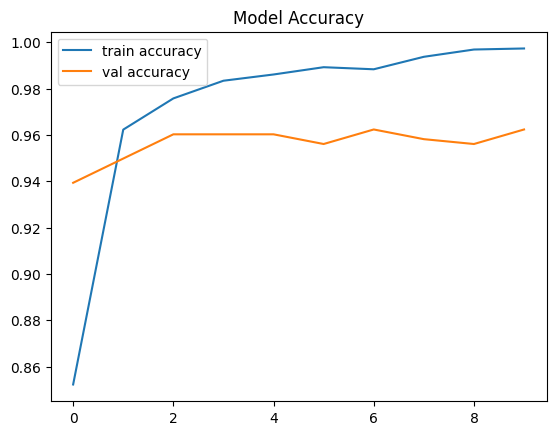

In [ ]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

Step 14: Plot training vs. validation loss curves for EfficientNetB0

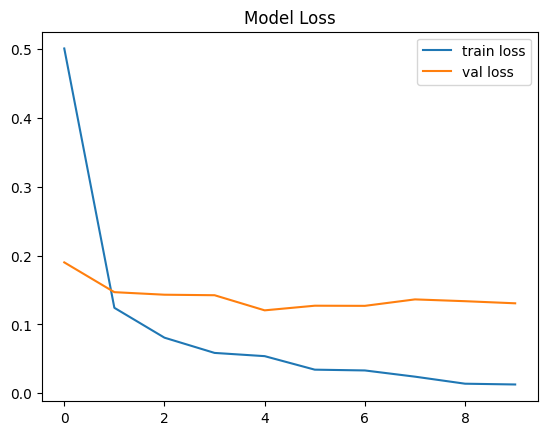

In [ ]:

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.legend()
plt.show()

Step 15: Plot confusion matrix heatmap for EfficientNetB0 predictions on test set


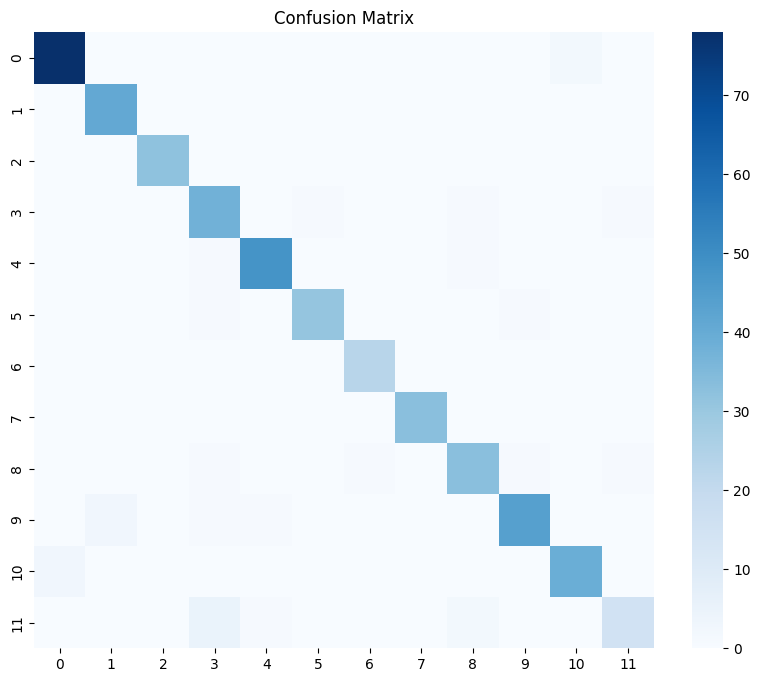

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Step 16: Print the detailed classification report for EfficientNetB0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        80
           1       0.93      1.00      0.96        41
           2       1.00      1.00      1.00        32
           3       0.81      0.93      0.86        41
           4       0.96      0.96      0.96        50
           5       0.97      0.94      0.95        33
           6       0.96      1.00      0.98        23
           7       1.00      1.00      1.00        33
           8       0.89      0.89      0.89        37
           9       0.96      0.90      0.93        49
          10       0.95      0.93      0.94        42
          11       0.88      0.65      0.75        23

    accuracy                           0.94       484
   macro avg       0.94      0.93      0.93       484
weighted avg       0.94      0.94      0.94       484



Step 17: Initialize a results dictionary to store accuracy and history for each model


In [ ]:
results = {}

Step 18: Store EfficientNetB0 test accuracy and training history in results dict


In [ ]:
results["EfficientNetB0"] = {
    "accuracy": test_acc,
    "history": history.history
}

Step 19: Import ResNet50 model and Keras layers/models for building the next model


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

Step 20: Load ResNet50 pretrained on ImageNet as the base model

In [ ]:
# include_top=False removes the classification head
# Freeze weights for transfer learning
base_model_resnet = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model_resnet.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 21: Build the full ResNet50 classification model


In [ ]:
# Same architecture as EfficientNetB0: pool -> dense(256) -> dropout -> dense(12)
model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(12, activation='softmax')
])

Step 22: Compile the ResNet50 model with the same settings as EfficientNetB0

In [ ]:

model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Step 23: Train ResNet50 on the training set for 10 epochs


In [ ]:
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 44s 436ms/step - accuracy: 0.7207 - loss: 0.8650 - val_accuracy: 0.8598 - val_loss: 0.4279
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.8752 - loss: 0.3626 - val_accuracy: 0.8598 - val_loss: 0.4062
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.9291 - loss: 0.2047 - val_accuracy: 0.8870 - val_loss: 0.3379
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9407 - loss: 0.1590 - val_accuracy: 0.8766 - val_loss: 0.3551
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9582 - loss: 0.1196 - val_accuracy: 0.8808 - val_loss: 0.3653
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.9735 - loss: 0.0816 - val_accuracy: 0.8828 - val_loss: 0.3645
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.9865 - loss: 0.0537 - val_accuracy: 0.8975 - val_loss: 0.3559
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.9852 - loss: 0.0411 - val_accu

Step 24: Evaluate ResNet50 on the test set and print test accuracy


In [ ]:
test_loss, test_acc_resnet = model_resnet.evaluate(test_ds)
print(test_acc_resnet)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.8843 - loss: 0.3227
0.8842975497245789


Step 25: Get predicted class labels for test set using ResNet50


In [ ]:
import numpy as np

y_pred_resnet = np.argmax(model_resnet.predict(test_ds), axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 357ms/step


Step 26: Store ResNet50 test accuracy and training history in results dict


In [ ]:
results["ResNet50"] = {
    "accuracy": test_acc_resnet,
    "history": history_resnet.history
}

Step 27: Import MobileNetV3Large model and Keras layers/models


In [ ]:
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras import layers, models

Step 28: Load MobileNetV3Large pretrained on ImageNet as the base model


In [ ]:
# include_top=False removes the classification head
# Freeze weights for transfer learning
base_model_mobile = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model_mobile.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 29: Build the full MobileNetV3Large classification model


In [ ]:
# Same architecture: pool -> dense(256) -> dropout -> dense(12)
model_mobile = models.Sequential([
    base_model_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(12, activation='softmax')
])

Step 30: Compile the MobileNetV3Large model


In [ ]:
model_mobile.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Step 31: Train MobileNetV3Large on the training set for 10 epochs


In [ ]:
history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 65s 615ms/step - accuracy: 0.8020 - loss: 0.6200 - val_accuracy: 0.9121 - val_loss: 0.2377
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.9367 - loss: 0.1861 - val_accuracy: 0.9247 - val_loss: 0.2089
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 185ms/step - accuracy: 0.9668 - loss: 0.1054 - val_accuracy: 0.9310 - val_loss: 0.2086
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.9722 - loss: 0.0844 - val_accuracy: 0.9351 - val_loss: 0.2189
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9843 - loss: 0.0573 - val_accuracy: 0.9331 - val_loss: 0.1958
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.9924 - loss: 0.0337 - val_accuracy: 0.9331 - val_loss: 0.2097
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.9928 - loss: 0.0332 - val_accuracy: 0.9393 - val_loss: 0.2124
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - accuracy: 0.9919 - loss: 0.0305 - val_accu

Step 32: Evaluate MobileNetV3Large on the test set and print test accuracy


In [ ]:
test_loss, test_acc_mobile = model_mobile.evaluate(test_ds)
print("MobileNetV3 Accuracy:", test_acc_mobile)

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 767ms/step - accuracy: 0.9339 - loss: 0.2282
MobileNetV3 Accuracy: 0.93388432264328


Step 33: Store MobileNetV3Large test accuracy and training history in results dict


In [ ]:
results["MobileNetV3"] = {
    "accuracy": test_acc_mobile,
    "history": history_mobile.history
}

Step 34: Create a pandas DataFrame summarizing accuracy of all three models


In [ ]:
# and print it for comparison
import pandas as pd

df = pd.DataFrame({
    "Model": ["EfficientNetB0", "ResNet50", "MobileNetV3"],
    "Accuracy": [
        results["EfficientNetB0"]["accuracy"],
        results["ResNet50"]["accuracy"],
        results["MobileNetV3"]["accuracy"]
    ]
})

print(df)

            Model  Accuracy
0  EfficientNetB0  0.940083
1        ResNet50  0.884298
2     MobileNetV3  0.933884


Step 35: Create export directory structure for saving models, plots, and results


In [ ]:
!mkdir -p export/models
!mkdir -p export/outputs
!mkdir -p export/results

Step 36: Save the trained EfficientNetB0 model in Keras format


In [ ]:
model.save("export/models/efficientnet.keras")

Step 37: Save the trained ResNet50 model in Keras format


In [ ]:
model_resnet.save("export/models/resnet.keras")

Step 38: Save the trained MobileNetV3Large model in Keras format


In [ ]:
model_mobile.save("export/models/mobilenet.keras")

Step 39: Define a helper function to save accuracy and loss plots for a model


In [ ]:
# Takes a history object and a name string, saves two PNG files
import matplotlib.pyplot as plt

def save_history_plot(history, name):
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{name} Accuracy')
    plt.legend(['train', 'val'])
    plt.savefig(f'export/outputs/{name}_accuracy.png')
    plt.close()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{name} Loss')
    plt.legend(['train', 'val'])
    plt.savefig(f'export/outputs/{name}_loss.png')
    plt.close()

Step 40: Generate and save accuracy/loss plots for all three models


In [ ]:
save_history_plot(history, "efficientnet")
save_history_plot(history_resnet, "resnet")
save_history_plot(history_mobile, "mobilenet")

Step 41: Define a helper function to save confusion matrix heatmaps


In [ ]:
# Takes true and predicted labels plus a name, saves a heatmap as PNG
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def save_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues", annot=False)
    plt.title(f"{name} Confusion Matrix")

    plt.savefig(f"export/outputs/{name}_cm.png")
    plt.close()

Step 42: Get MobileNetV3Large predictions on the test set


In [ ]:
# Then save confusion matrix heatmaps for all three models
import numpy as np

y_pred_mobile = np.argmax(model_mobile.predict(test_ds), axis=1)

save_confusion_matrix(y_true, y_pred, "efficientnet")
save_confusion_matrix(y_true, y_pred_resnet, "resnet")
save_confusion_matrix(y_true, y_pred_mobile, "mobilenet")

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 503ms/step


Step 43: Extract true labels from the test dataset


In [ ]:
# (used for ResNet50 evaluation if needed)
y_true_resnet = np.concatenate([y for x, y in test_ds], axis=0)

Step 44: Create a comparison DataFrame with all three model accuracies


In [ ]:
# and save it as a CSV file
import pandas as pd

df = pd.DataFrame({
    "Model": ["EfficientNetB0", "ResNet50", "MobileNetV3"],
    "Accuracy": [
        test_acc,
        test_acc_resnet,
        test_acc_mobile
    ]
})

df.to_csv("export/results/comparison.csv", index=False)

 Step 45: Zip the entire export folder for easy download


In [ ]:
!zip -r fyp_project_export.zip export

  adding: export/ (stored 0%)
  adding: export/outputs/ (stored 0%)
  adding: export/outputs/efficientnet_cm.png (deflated 26%)
  adding: export/outputs/mobilenet_accuracy.png (deflated 13%)
  adding: export/outputs/efficientnet_accuracy.png (deflated 11%)
  adding: export/outputs/mobilenet_loss.png (deflated 10%)
  adding: export/outputs/resnet_loss.png (deflated 9%)
  adding: export/outputs/efficientnet_loss.png (deflated 10%)
  adding: export/outputs/resnet_cm.png (deflated 26%)
  adding: export/outputs/mobilenet_cm.png (deflated 26%)
  adding: export/outputs/resnet_accuracy.png (deflated 9%)
  adding: export/results/ (stored 0%)
  adding: export/results/comparison.csv (deflated 8%)
  adding: export/models/ (stored 0%)
  adding: export/models/efficientnet.keras (deflated 11%)
  adding: export/models/resnet.keras (deflated 8%)
  adding: export/models/mobilenet.keras (deflated 11%)


Step 46: Download the zipped export folder from Google Colab to local machine


In [ ]:
from google.colab import files
files.download("fyp_project_export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>